In [2]:
import os
import math
import random
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance

import cv2
import numpy as np
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torchvision.transforms import InterpolationMode

import gc
from tqdm import tqdm
import matplotlib.pyplot as plt

from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_dir = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles_preprocess/images_wrinkles_preprocess")
mask_dir = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks")

torch.backends.cudnn.benchmark = True
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
class RandomGamma:
    def __init__(self, gamma_range=(0.9, 1.1), p=0.3):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        gamma = random.uniform(*self.gamma_range)
        return TF.adjust_gamma(img, gamma)


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.6), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        radius = random.uniform(*self.radius_range)
        return img.filter(ImageFilter.GaussianBlur(radius))


class CLAHELabTransform:
    def __init__(self, clip_limit=1, tile_grid_size=(8, 8), p=0.25):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )
        l = clahe.apply(l)

        lab = cv2.merge([l, a, b])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(out)


class WrinkleSegDatasetV2(Dataset):
    def __init__(self, pairs, img_size=1024, train=False, rgb=True):
        self.pairs = pairs
        self.train = train
        self.rgb = rgb
        self.img_size = img_size

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015
            ),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path)
        img = img.convert("RGB") if self.rgb else img.convert("L")
        mask = Image.open(mask_path).convert("L")

        # resize first
        img = TF.resize(img, [self.img_size, self.img_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=InterpolationMode.NEAREST)

        # geometric aug (same for image & mask)
        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            img = self.color_aug(img)

        x = TF.to_tensor(img)
        x = self.normalize(x)

        y = TF.to_tensor(mask)
        y = (y > 0.5).float()

        return x, y


class SegFormerBinaryV2(nn.Module):
    def __init__(self, model_name="nvidia/segformer-b2-finetuned-ade-512-512", dropout=0.1):
        super().__init__()

        self.model = SegformerForSemanticSegmentation.from_pretrained(
            model_name,
            num_labels=1,
            ignore_mismatched_sizes=True
        )

        # невеликий dropout перед head
        if hasattr(self.model.decode_head, "dropout"):
            self.model.decode_head.dropout.p = dropout

    def forward(self, x):
        out = self.model(pixel_values=x)
        logits = out.logits

        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        return logits


@torch.no_grad()
def dice_per_image_from_logits(logits, targets, eps=1e-7, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    targets = targets.float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * inter + eps) / (union + eps)
    return dice


@torch.no_grad()
def dice_coef_from_logits(logits, targets, eps=1e-7, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float()
    targets = targets.float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    return ((2 * inter + eps) / (union + eps)).mean()


@torch.no_grad()
def iou_from_logits(logits, targets, eps=1e-7, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float()
    targets = targets.float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - inter

    return ((inter + eps) / (union + eps)).mean()


class SoftDiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        inter = (probs * targets).sum(dim=1)
        denom = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * inter + self.eps) / (denom + self.eps)
        return 1 - dice.mean()


class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, eps=1e-7):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        tp = (probs * targets).sum(dim=1)
        fp = (probs * (1 - targets)).sum(dim=1)
        fn = ((1 - probs) * targets).sum(dim=1)

        tversky = (tp + self.eps) / (tp + self.alpha * fp + self.beta * fn + self.eps)
        return 1 - tversky.mean()


bce = nn.BCEWithLogitsLoss()
dice_loss = SoftDiceLoss()
tversky_loss = TverskyLoss(alpha=0.3, beta=0.7)

def loss_fn(logits, targets):
    loss_bce = bce(logits, targets.float())
    loss_dice = dice_loss(logits, targets)
    loss_tversky = tversky_loss(logits, targets)
    return 0.45 * loss_bce + 0.30 * loss_dice + 0.25 * loss_tversky


@torch.no_grad()
def evaluate(model, dl, device, use_amp=True):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n = 0

    amp_enabled = use_amp and (device.type == "cuda")

    for x, y in dl:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(x)
            loss = loss_fn(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_dice += dice_coef_from_logits(logits, y).item() * bs
        total_iou += iou_from_logits(logits, y).item() * bs
        n += bs

        del x, y, logits, loss

    return {
        "loss": total_loss / n,
        "dice": total_dice / n,
        "iou": total_iou / n,
    }


def train_one_epoch(
    model,
    dl,
    optimizer,
    device,
    ep,
    epochs,
    scaler=None,
    grad_clip=1.0,
    accum_steps=4,
):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    n = 0

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(dl, desc=f"epoch {ep+1}/{epochs}", leave=False)

    amp_enabled = (scaler is not None) and (device.type == "cuda")

    for step, (imgs, masks) in enumerate(pbar):
        x = imgs.to(device, non_blocking=True)
        y = masks.to(device, non_blocking=True)

        if amp_enabled:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(x)
                loss = loss_fn(logits, y)

            loss_for_backward = loss / accum_steps
            scaler.scale(loss_for_backward).backward()

            if (step + 1) % accum_steps == 0 or (step + 1) == len(dl):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
        else:
            logits = model(x)
            loss = loss_fn(logits, y)

            loss_for_backward = loss / accum_steps
            loss_for_backward.backward()

            if (step + 1) % accum_steps == 0 or (step + 1) == len(dl):
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

        bs = x.size(0)

        with torch.no_grad():
            dice = dice_coef_from_logits(logits, y).item()

        total_loss += loss.item() * bs
        total_dice += dice * bs
        n += bs

        pbar.set_postfix({
            "loss": f"{total_loss / n:.4f}",
            "dice": f"{total_dice / n:.4f}"
        })

        del x, y, imgs, masks, logits, loss, loss_for_backward

    return {"loss": total_loss / n,
        "dice": total_dice / n
    }


def forward_logits(model, imgs):
    out = model(imgs)

    if isinstance(out, torch.Tensor):
        logits = out
    elif hasattr(out, "logits"):
        logits = out.logits
    elif isinstance(out, dict) and "logits" in out:
        logits = out["logits"]
    else:
        raise TypeError("Не вдалося витягнути logits з output моделі.")

    if logits.shape[-2:] != imgs.shape[-2:]:
        logits = torch.nn.functional.interpolate(
            logits,
            size=imgs.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

    return logits


@torch.no_grad()
def evaluate_segmentation_metrics(model, loader, device, threshold=0.5, eps=1e-8):
    model.eval()

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).float()

        logits = forward_logits(model, imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks)).sum().item()
        fn = ((1 - preds) * masks).sum().item()
        tn = ((1 - preds) * (1 - masks)).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
    }


@torch.no_grad()
def get_predictions_vit(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device, non_blocking=True)
    masks = masks.to(device, non_blocking=True).float()

    logits = forward_logits(model, imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), probs.cpu(), preds.cpu()


def compute_metrics_single(pred, gt, eps=1e-8):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)

    return dice, iou


def denormalize_if_needed(img):
    img = img.numpy().transpose(1, 2, 0)

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img


def make_error_overlay(img, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = img.copy()

    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


def visualize_predictions_grid(imgs, masks, preds, n=4):
    n = min(n, len(imgs))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = denormalize_if_needed(imgs[i])
        gt = masks[i, 0].numpy()
        pred = preds[i, 0].numpy()

        dice, iou = compute_metrics_single(pred, gt)
        overlay = make_error_overlay(img, pred, gt, alpha=0.45)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice={dice:.3f}  IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay\nGreen=TP  Red=FP  Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


import torch
import matplotlib.pyplot as plt
import numpy as np

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize_image(x, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """
    x: tensor [C, H, W] after normalization
    returns: tensor [C, H, W] in [0, 1]
    """
    x = x.detach().cpu()
    x = x * std + mean
    x = torch.clamp(x, 0, 1)
    return x

def show_dataset_samples(dataset, indices=None, n=4, figsize=(15, 5), overlay_alpha=0.35):
    """
    Показує:
    - image
    - mask
    - overlay
    
    Args:
        dataset: твій Dataset
        indices: список індексів, які хочеш показати
        n: якщо indices=None, то скільки випадкових прикладів взяти
        figsize: розмір фігури
        overlay_alpha: прозорість маски на оверлеї
    """
    if indices is None:
        indices = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    else:
        n = len(indices)

    fig, axes = plt.subplots(n, 3, figsize=(figsize[0], figsize[1] * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        x, y = dataset[idx]   # x: [C,H,W], y: [1,H,W]

        # image
        if x.shape[0] == 3:
            img = denormalize_image(x).permute(1, 2, 0).numpy()
        else:
            img = x.squeeze(0).detach().cpu().numpy()

        # mask
        mask = y.squeeze(0).detach().cpu().numpy()

        # overlay
        if x.shape[0] == 3:
            overlay = img.copy()
            red_mask = np.zeros_like(overlay)
            red_mask[..., 0] = 1.0
            overlay = np.where(mask[..., None] > 0.5,
                               (1 - overlay_alpha) * overlay + overlay_alpha * red_mask,
                               overlay)
        else:
            overlay = img.copy()

        # plot image
        axes[row, 0].imshow(img, cmap='gray' if x.shape[0] == 1 else None)
        axes[row, 0].set_title(f"Image | idx={idx}")
        axes[row, 0].axis("off")

        # plot mask
        axes[row, 1].imshow(mask, cmap='gray')
        axes[row, 1].set_title("Mask")
        axes[row, 1].axis("off")

        # plot overlay
        axes[row, 2].imshow(overlay, cmap='gray' if x.shape[0] == 1 else None)
        axes[row, 2].set_title("Overlay")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()


def show_batch_with_masks(loader):
    imgs, masks = next(iter(loader))

    imgs = imgs.cpu()
    masks = masks.cpu()

    B = imgs.shape[0]

    fig, axes = plt.subplots(2, B, figsize=(3 * B, 6))

    for i in range(B):

        img = denormalize(imgs[i], IMAGENET_MEAN, IMAGENET_STD)

        img = img.numpy().transpose(1, 2, 0)
        mask = masks[i, 0].numpy()

        img = np.clip(img, 0, 1)

        axes[0, i].imshow(img)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].axis("off")

    axes[0, B // 2].set_title("Top: Images | Bottom: Masks")

    plt.tight_layout()
    plt.show()


def denormalize(img, mean, std):
    """
    img: tensor [C,H,W]
    """
    img = img.clone()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    return img

In [4]:
image_paths = sorted(img_dir.glob("*.png"))

pairs = []

for img_path in image_paths:
    mask_path = mask_dir / img_path.name
    
    if mask_path.exists():
        pairs.append((img_path, mask_path))
    else:
        print(f"⚠ Mask not found for {img_path.name}")

print(f"Recovered {len(pairs)} pairs successfully.")
pairs[:3]

Recovered 1000 pairs successfully.


[(PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles_preprocess/images_wrinkles_preprocess/00001.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00001.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles_preprocess/images_wrinkles_preprocess/00011.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00011.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles_preprocess/images_wrinkles_preprocess/00016.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00016.png'))]

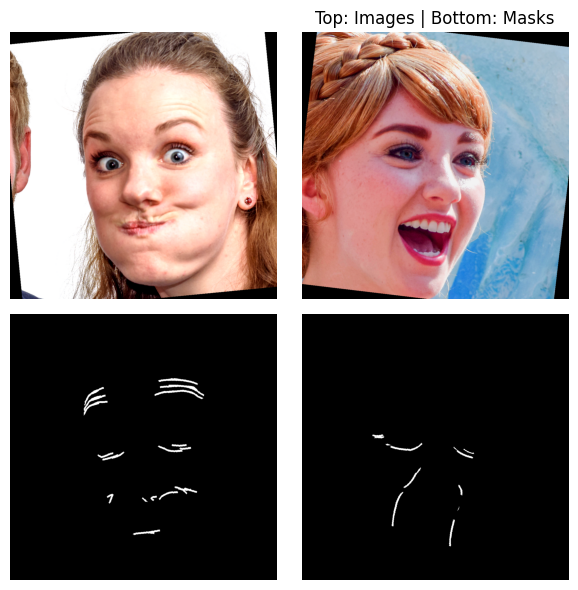

train/dev/test: 800 100 100


In [5]:
IMG_SIZE = 1024
BATCH_SIZE = 2
NUM_EPOCHS = 45

train_pairs, temp_pairs = train_test_split(
    pairs, test_size=0.2, random_state=42, shuffle=True
)

dev_pairs, test_pairs = train_test_split(
    temp_pairs, test_size=0.5, random_state=42, shuffle=True
)

ds_tr = WrinkleSegDatasetV2(train_pairs, img_size=IMG_SIZE, train=True, rgb=True)
ds_dev = WrinkleSegDatasetV2(dev_pairs, img_size=IMG_SIZE, train=False, rgb=True)
ds_te = WrinkleSegDatasetV2(test_pairs, img_size=IMG_SIZE, train=False, rgb=True)

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
dl_dev = DataLoader(ds_dev, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

show_batch_with_masks(dl_tr)

print("train/dev/test:", len(ds_tr), len(ds_dev), len(ds_te))

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = SegFormerBinaryV2(
    model_name="nvidia/segformer-b2-finetuned-ade-512-512",
    dropout=0.1
).to(device)

# print("Using", torch.cuda.device_count(), "GPUs")
# model = torch.nn.DataParallel(model)

model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=8,
    T_mult=1,
    eta_min=1e-6
)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if use_amp else None

Device: cuda


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

In [7]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
best_dice = -1.0
num_epochs = 45

history = {
    "epoch": [],
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "lr": [],
}

for epoch in range(0, num_epochs):
    tr_loss = train_one_epoch(model, dl_tr, optimizer, device, epoch, num_epochs, scaler=scaler)
    va = evaluate(model, dl_dev, device)

    lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss['loss'])
    history["train_dice"].append(tr_loss['dice'])
    history["val_loss"].append(va["loss"])
    history["val_dice"].append(va["dice"])
    history["val_iou"].append(va["iou"])
    history["lr"].append(lr)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={tr_loss['loss']:.4f} | "
        f"train_dice={tr_loss['dice']:.4f} | "
        f"val_loss={va['loss']:.4f} | "
        f"val_dice={va['dice']:.4f} | "
        f"val_iou={va['iou']:.4f} | "
        f"lr={lr:.6f}"
    )

    if va["dice"] > best_dice:
        best_dice = va["dice"]
        torch.save(model.state_dict(), "best_segformer_wrinkles.pt")
        print(f"  -> saved best model, val_dice={best_dice:.4f}")

    scheduler.step()


epoch 1/45: 100%|██████████| 400/400 [08:01<00:00,  1.16s/it, loss=0.6697, dice=0.1578]
                                                                                       

Epoch 00/45 | train_loss=0.6697 | train_dice=0.1578 | val_loss=0.5574 | val_dice=0.3367 | val_iou=0.2079 | lr=0.000100
  -> saved best model, val_dice=0.3367


Epoch 01/45 | train_loss=0.5195 | train_dice=0.3534 | val_loss=0.4624 | val_dice=0.4295 | val_iou=0.2790 | lr=0.000096
  -> saved best model, val_dice=0.4295


epoch 3/45:  34%|███▎      | 134/400 [02:25<04:50,  1.09s/it, loss=0.4591, dice=0.4123]

In [8]:
model.load_state_dict(torch.load("/kaggle/working/best_segformer_wrinkles.pt", map_location=device))
model.eval()


val_metrics = evaluate_segmentation_metrics(model, dl_te, device)
print(val_metrics)

{'accuracy': 0.9940490531921385, 'precision': 0.5796518790575094, 'recall': 0.602171316845618, 'iou': 0.41914128132926465, 'dice': 0.5906970459441054}


In [9]:
imgs_all = []
masks_all = []

for i, (imgs, masks) in enumerate(dl_te):
    if i >= 2:
        break
    imgs_all.append(imgs)
    masks_all.append(masks)

imgs_all = torch.cat(imgs_all, dim=0)
masks_all = torch.cat(masks_all, dim=0)

imgs, masks, probs, preds = get_predictions_vit(model, [(imgs_all, masks_all)], device)

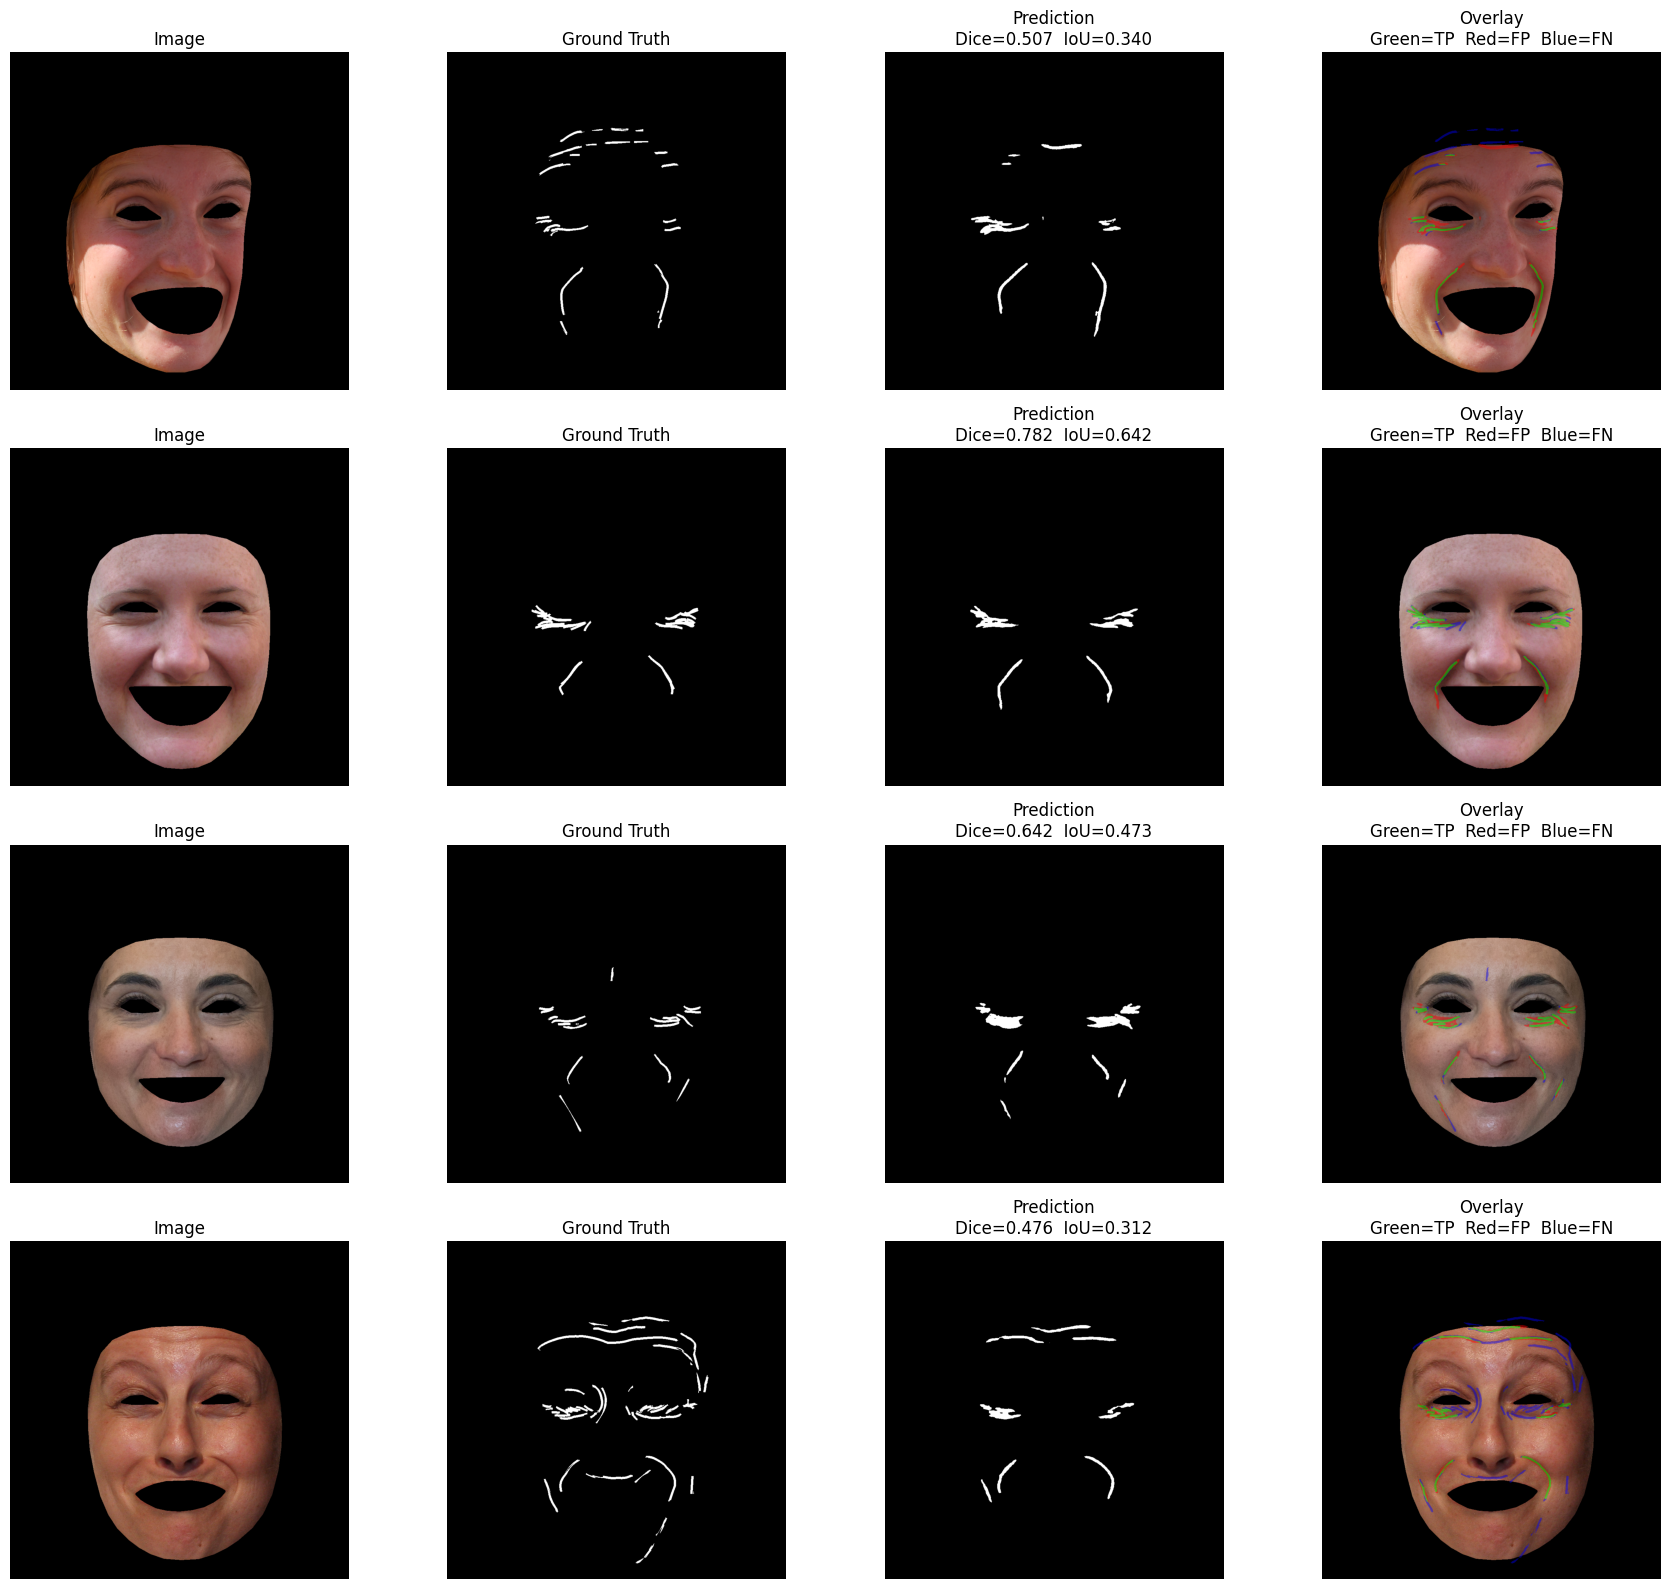

In [10]:
visualize_predictions_grid(imgs, masks, preds, n=10)